In [2]:
import pandas as pd
df = pd.read_csv('/content/Bank_Churn.csv')

In [3]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [5]:
categorical_cols_list = df.select_dtypes(include = 'object').columns.tolist()[1:]

In [6]:
numeric_cols_list = df.select_dtypes(include=['int64', 'float64']).columns.tolist()[1:]

In [7]:
categorical_cols_list

['Geography', 'Gender']

In [8]:
numeric_cols_list

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [9]:
for i in categorical_cols_list:
  print(df[i].value_counts())
  print('----------------------------------------')

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
----------------------------------------
Gender
Male      5457
Female    4543
Name: count, dtype: int64
----------------------------------------


In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib
import numpy as np
import matplotlib.pyplot as pltt as plt
import seaborn as sns

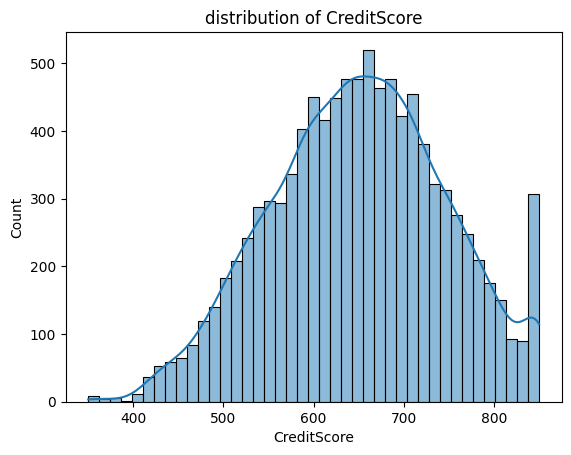

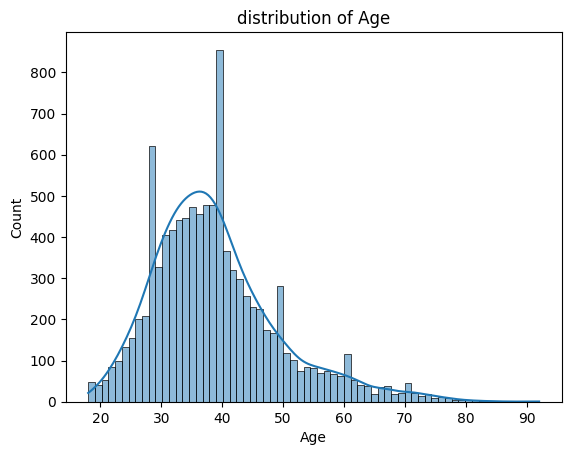

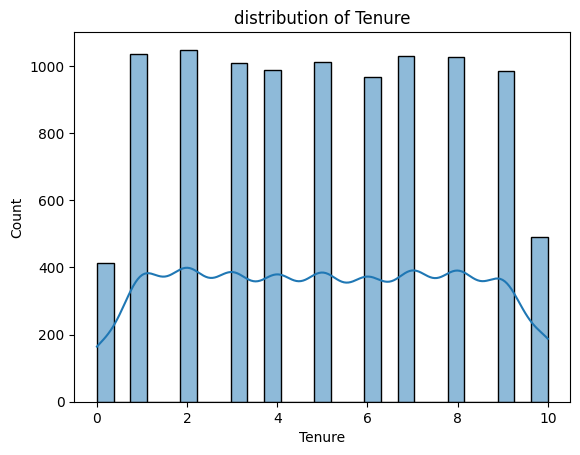

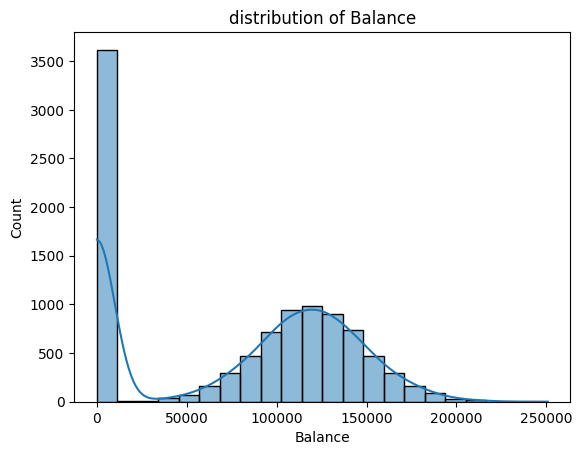

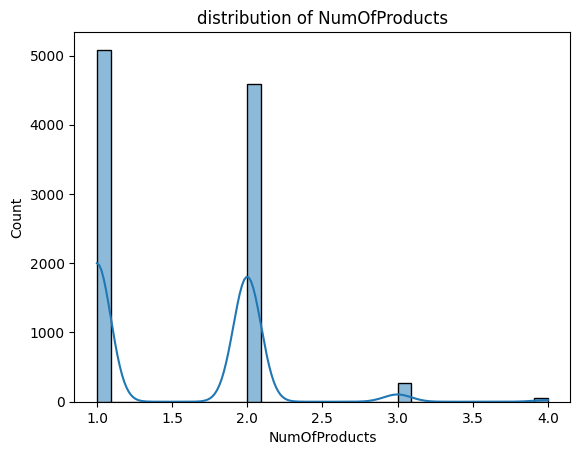

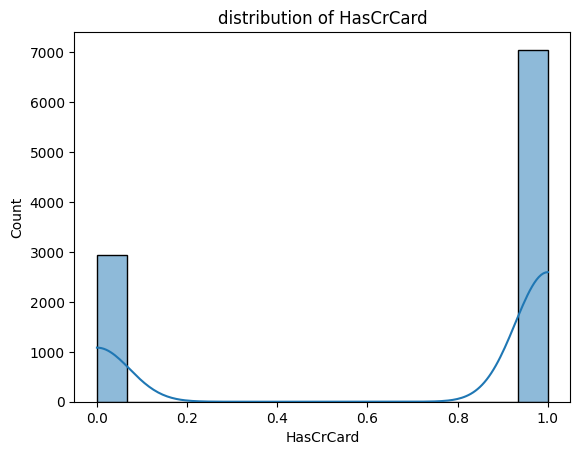

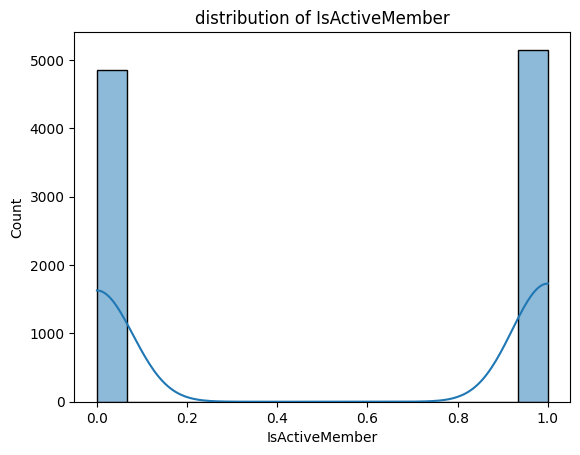

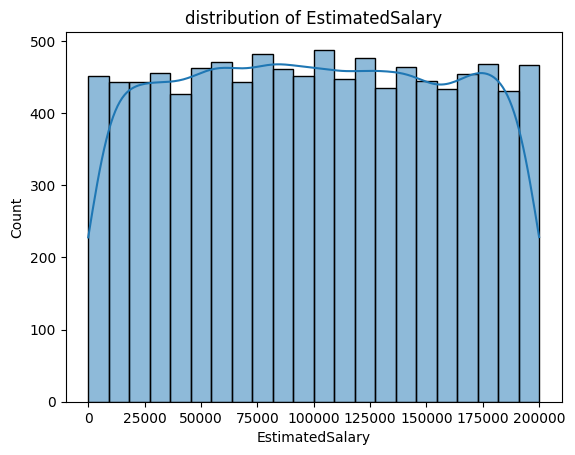

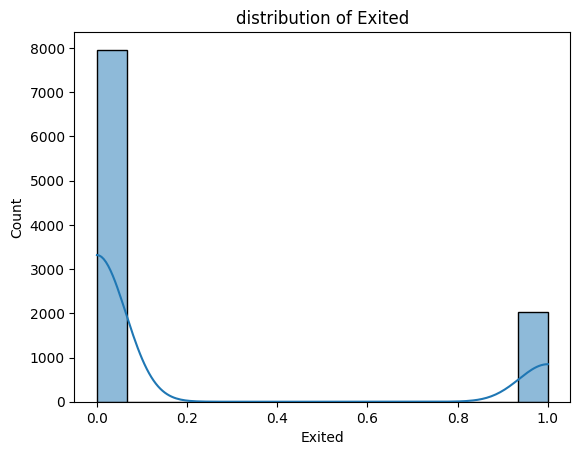

In [11]:
import seaborn as sns
for i in numeric_cols_list:
  plt.figure()
  sns.histplot(df[i], kde=True)
  plt.title(f'distribution of {i}')
  plt.show()

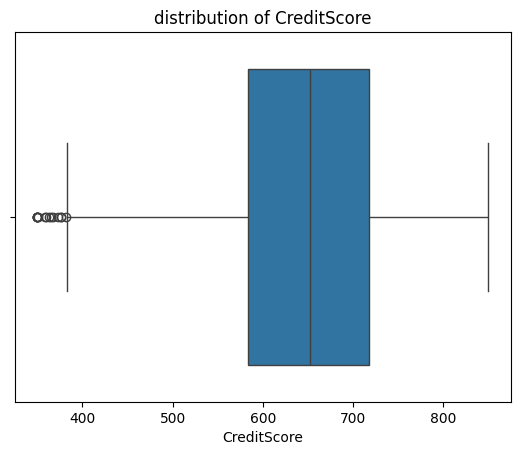

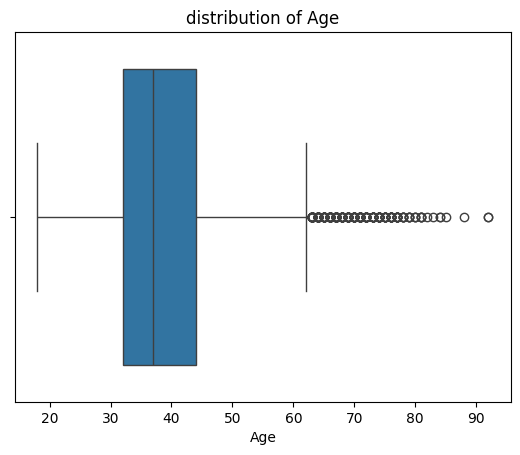

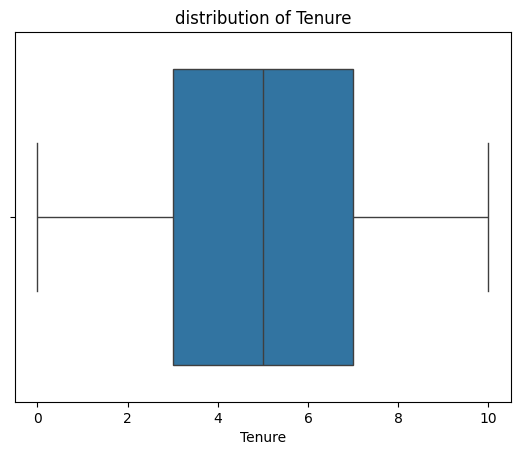

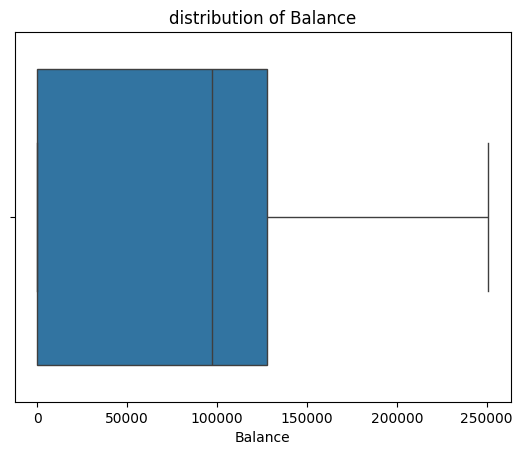

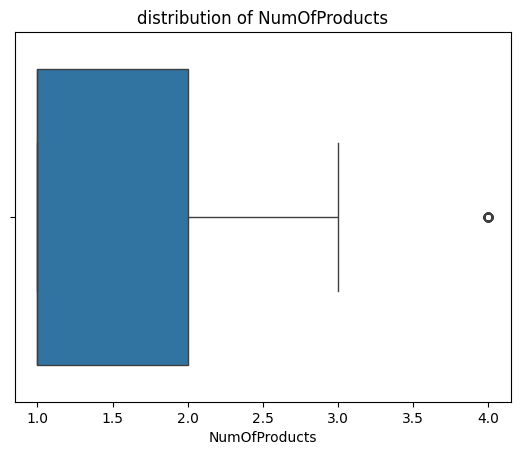

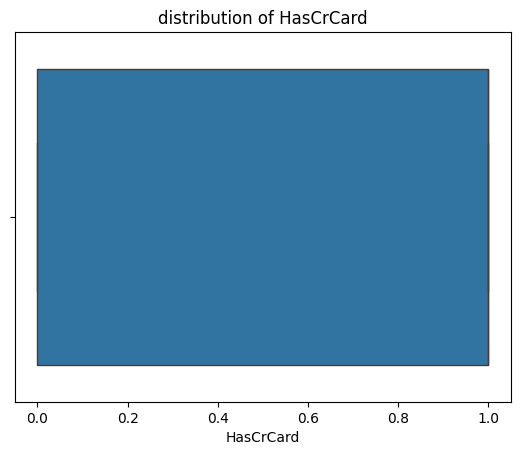

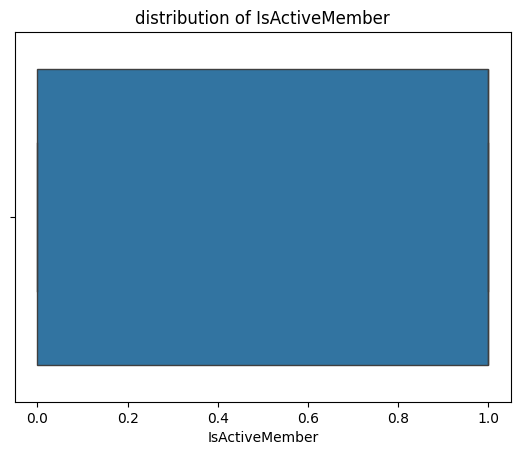

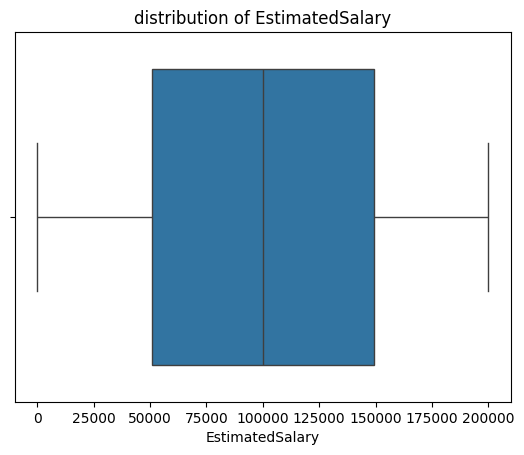

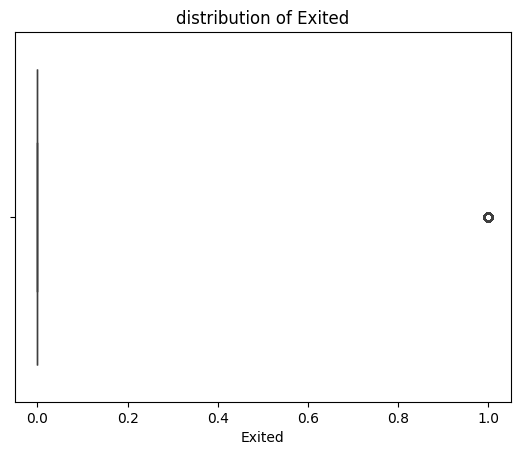

In [12]:
import seaborn as sns
for i in numeric_cols_list:
  plt.figure()
  sns.boxplot(x=df[i])
  plt.title(f'distribution of {i}')
  plt.show()

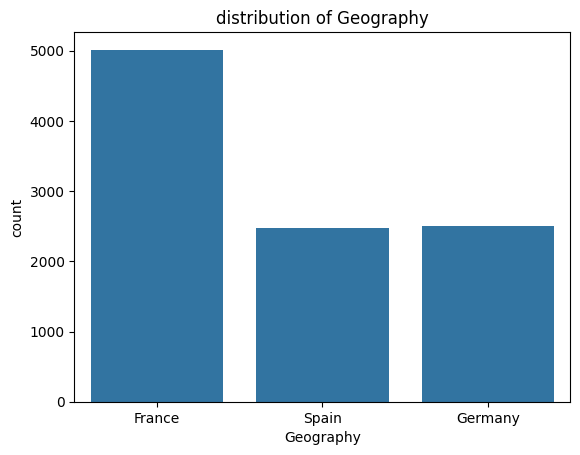

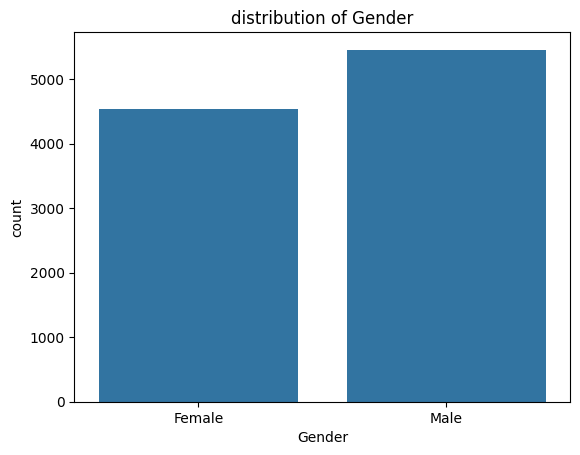

In [13]:
import seaborn as sns
for i in categorical_cols_list:
  plt.figure()
  sns.countplot(x = df[i])
  plt.title(f'distribution of {i}')
  plt.show()

In [14]:
x = df.iloc[:, 1:-1]
y =df.iloc[:, -1]

In [15]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Surname          10000 non-null  object 
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  object 
 3   Gender           10000 non-null  object 
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [18]:
numeric_cols_list = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_list = x.select_dtypes(include='object').columns.tolist()

In [19]:
from pandas.core.arrays import categorical
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot' , OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols_list),
    ('cat' , categorical_transformer, categorical_cols_list)
])

In [21]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'NumOfProducts', 'HasCrCard',
                                  'IsActiveMember', 'EstimatedSalary']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Surname', 'Geography', 'Gender'])])

In [22]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [23]:
log_reg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Surname', 'Geography',
                                                   'Gender'])])),
                ('calssifier', LogisticRegression())])

In [24]:
log_reg_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Surname', 'Geography',
                                                   'Gender'])])),
                ('calssifier', LogisticRegression())])

In [25]:
y_pred_log = log_reg_pipeline.predict(x_test)

In [26]:
print("calssificatio report for logistic regression")
print(classification_report(y_test, y_pred_log))

calssificatio report for logistic regression
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1607
           1       0.52      0.21      0.30       393

    accuracy                           0.81      2000
   macro avg       0.68      0.58      0.59      2000
weighted avg       0.77      0.81      0.77      2000



In [27]:
confusion_matrix(y_test ,y_pred_log)

array([[1532,   75],
       [ 312,   81]])

In [40]:
joblib.dump(log_reg_pipeline, 'bank.joblib')
print('model saved! ')

model saved! 


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [29]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

In [30]:
dt_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Surname', 'Geography',
                                                   'Gender'])])),
                ('calssifier', DecisionTreeClassifier())])

In [31]:
y_pred = dt_pipeline.predict(x_test)

In [32]:
print("calssificatio report for decision tree")
print(classification_report(y_test, y_pred))

calssificatio report for decision tree
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1607
           1       0.53      0.51      0.52       393

    accuracy                           0.81      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.81      0.81      0.81      2000



In [33]:
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [i for i in range(1, 10) ]
}

In [34]:
dt_Pipeline= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [35]:
grid = GridSearchCV(
    estimator=dt_Pipeline ,
    param_grid= param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
    )

In [36]:
grid.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['CreditScore',
                                                                          'Age',
                                                                          'Tenure',
                                                                          'Balance',
                                                                          'NumOfProducts',
                                                                          'HasCrCard',
                                                                          'IsActiveMember',
                                                                          'EstimatedSalary']...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Surname',
                                                                          'Geography',
                                                                          'Gender'])])),
                                       ('classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [None, 3, 5, 10, 20],
                         'classifier__min_samples_leaf': [1, 2, 3, 4, 5, 6, 7,
                                                          8, 9],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [37]:
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
best_model = grid.best_estimator_

Best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 2}
Best CV score: 0.8561


In [38]:
from pickle import dump

In [39]:
dump(best_model, open(r'model.pkl', 'wb'))

NameError: name 'model' is not defined